In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
creep = pd.read_csv("data/Creep.csv", encoding='latin-1')
creep.head()

,SetName,Cycle,Time_S,Temperature_°C,X_Displacement_um,Y_Displacement_um,X_Force_mN,Y_Force_mN,X_MeasuredStrain_%,Y_MeasuredStrain_%
0,Precon1,1-Preload,0.0,23.7,0,0,-12,12,-1.734720e-16,1.387780e-15
1,Precon1,1-Preload,0.1,23.7,20,0,10,1,-3.673330e-05,-1.302734e-02
2,Precon1,1-Preload,0.2,23.7,40,0,10,4,7.907824e-02,-3.500897e-02
3,Precon1,1-Preload,0.3,23.7,60,0,9,0,1.455805e-01,-7.469723e-02
4,Precon1,1-Preload,0.4,23.7,80,0,14,1,2.220930e-01,-1.040976e-01


In [3]:
# cross sectional area
width = 5.56e-3      # m
thickness = 1.9e-3   # m
A = width * thickness

In [4]:
# Extract Creep test data
t_creep = creep["Time_S"].to_numpy()
strain_creep_exp = creep["X_MeasuredStrain_%"].to_numpy() / 100
force_N_creep = creep["X_Force_mN"].to_numpy() * 1e-3
stress_creep_exp = force_N_creep / A

In [5]:
# For creep test, stress is constant; using average stress
sigma0 = np.mean(stress_creep_exp)

def sls_creep(t, E1, E2, eta):
    tau = eta * (E1 + E2) / (E1 * E2)
    return (sigma0 / E1) * (1 - (E2 / (E1 + E2)) * np.exp(-t / tau))

# Initial guesses
p0 = [1e5, 1e5, 1e6]

# Fit
params, cov = curve_fit(
    sls_creep,
    t_creep,
    strain_creep_exp,
    p0=p0,
    bounds=(0, np.inf),
    maxfev=10000
)

E1_c, E2_c, eta_c = params
print("E1 =", E1_c, "Pa")
print("E2 =", E2_c, "Pa")
print("eta =", eta_c, "Pa.s")

E1 = 140843.6051652542 Pa
E2 = 2240366492569.232 Pa
eta = 11058970.51686586 Pa.s


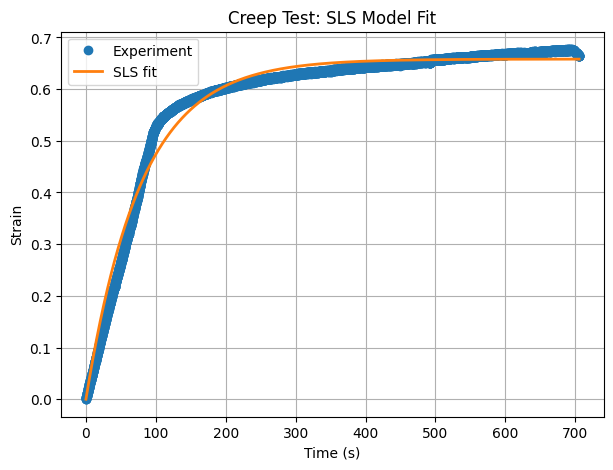

In [6]:
# Plot
strain_fit = sls_creep(t_creep, E1_c, E2_c, eta_c)

plt.figure(figsize=(7,5))
plt.plot(t_creep, strain_creep_exp, "o", label="Experiment")
plt.plot(t_creep, strain_fit, "-", linewidth=2, label="SLS fit")
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Creep Test: SLS Model Fit")
plt.legend()
plt.grid(True)
plt.savefig("figures/creep_fit.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
relax = pd.read_csv("data/Relaxation.csv", encoding='latin-1')
relax.head()

,SetName,Cycle,Time_S,Temperature_°C,X_Displacement_um,Y_Displacement_um,X_Force_mN,Y_Force_mN,X_MeasuredStrain_%,Y_MeasuredStrain_%
0,Precon1,1-Stretch,0.0,23.8,0,0,18,7,3.295970e-15,1.040830e-15
1,Precon1,1-Stretch,0.1,23.8,124,0,24,0,1.168638e-01,-1.588818e-01
2,Precon1,1-Stretch,0.2,23.8,256,0,32,5,3.415892e-01,-4.542762e-01
3,Precon1,1-Stretch,0.3,23.8,389,0,41,2,6.195209e-01,-7.849683e-01
4,Precon1,1-Stretch,0.4,23.8,521,0,53,-2,8.534429e-01,-9.564554e-01


In [8]:
# Extract Relaxation test data
t_relax = relax["Time_S"].to_numpy()
force_N_relax = relax["X_Force_mN"].to_numpy() * 1e-3
stress_relax_exp = force_N_relax / A
strain_relax_exp = relax["X_MeasuredStrain_%"].to_numpy() / 100


In [9]:
# crop relaxation hold region
mask = (t_relax >= 10) & (t_relax <= 610)

t_relax_crop = t_relax[mask]
stress_relax_crop = stress_relax_exp[mask]
strain_relax_crop = strain_relax_exp[mask]

# reset time so relaxation starts at t = 0
t_relax_crop = t_relax_crop - t_relax_crop[0]

In [10]:
eps0 = np.mean(strain_relax_crop)

def sls_relaxation(t, E1, E2, eta):
    return eps0 * (E1 + E2 * np.exp(-E2 * t / eta))

p0 = [1e5, 1e5, 1e6]

params, cov = curve_fit(
    sls_relaxation,
    t_relax_crop,
    stress_relax_crop,
    p0=p0,
    bounds=(0, np.inf),
    maxfev=10000
)

E1_r, E2_r, eta_r = params
print("E1 =", E1_r, "Pa")
print("E2 =", E2_r, "Pa")
print("eta =", eta_r, "Pa.s")


E1 = 165389.2819441156 Pa
E2 = 45364.86957904435 Pa
eta = 5538772.869627094 Pa.s


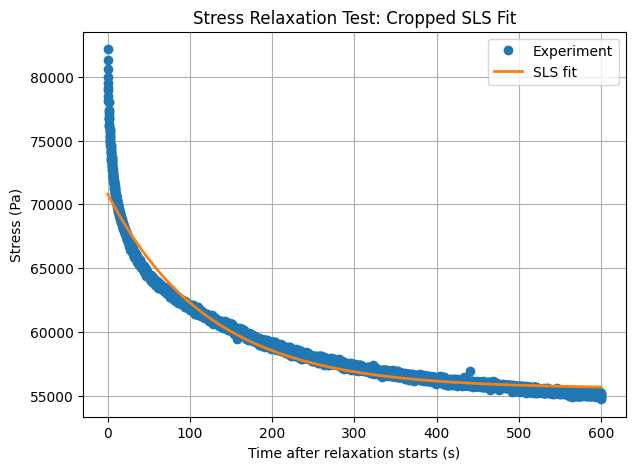

In [11]:
stress_fit = sls_relaxation(t_relax_crop, E1_r, E2_r, eta_r)

plt.figure(figsize=(7,5))
plt.plot(t_relax_crop, stress_relax_crop, "o", label="Experiment")
plt.plot(t_relax_crop, stress_fit, "-", linewidth=2, label="SLS fit")
plt.xlabel("Time after relaxation starts (s)")
plt.ylabel("Stress (Pa)")
plt.title("Stress Relaxation Test: Cropped SLS Fit")
plt.legend()
plt.grid(True)
plt.savefig("figures/relaxation_fit_cropped.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
E1_mean = np.mean([E1_c, E1_r])
E2_mean = np.mean([E2_c, E2_r])
eta_mean = np.mean([eta_c, eta_r])

print("Average E1 =", E1_mean, "Pa")
print("Average E2 =", E2_mean, "Pa")
print("Average eta =", eta_mean, "Pa.s")

Average E1 = 153116.4435546849 Pa
Average E2 = 1120183268967.0508 Pa
Average eta = 8298871.693246477 Pa.s
